In [1]:
from run_simulation import run_simulation, print_statistics
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt

# Common parameters for both analyses
NUM_PERMITS = 6410
RANDOM_SEED = 36
INTER_ARRIVAL_TIME = 0.0  # run permits back-to-back

In [2]:
# Run all three simulations
print(f"Running standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="none",
)

print(f"\nRunning initial AI check simulation with {NUM_PERMITS} permits...")
sim_initial = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="initial_check",
)

print(f"\nRunning full AI review simulation with {NUM_PERMITS} permits...")
sim_full = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
    ai_review="full_review",
)

Running standard simulation with 6410 permits...

Running initial AI check simulation with 6410 permits...

Running full AI review simulation with 6410 permits...


In [3]:
# Print statistics for each process
print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("=== AI INITIAL CHECK PROCESS ===")
stats_initial = sim_initial.get_statistics()
print_statistics(stats_initial)

print("\n=== AI FULL REVIEW PROCESS ===")
stats_full = sim_full.get_statistics()
print_statistics(stats_full)

=== STANDARD PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4632 (72.26%)
  CUSTOM_NON_LIKE               : 1158 (18.07%)
  PRE_APPROVED_LIKE             :  110 ( 1.72%)
  PRE_APPROVED_NON_LIKE         :   29 ( 0.45%)
  SELF_CERT_LIKE                :  391 ( 6.10%)
  SELF_CERT_NON_LIKE            :   90 ( 1.40%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     271.37 days
  Median:   259.34 days
  Std Dev:  117.36 days
  Min:       60.85 days
  Max:     1448.17 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT
-

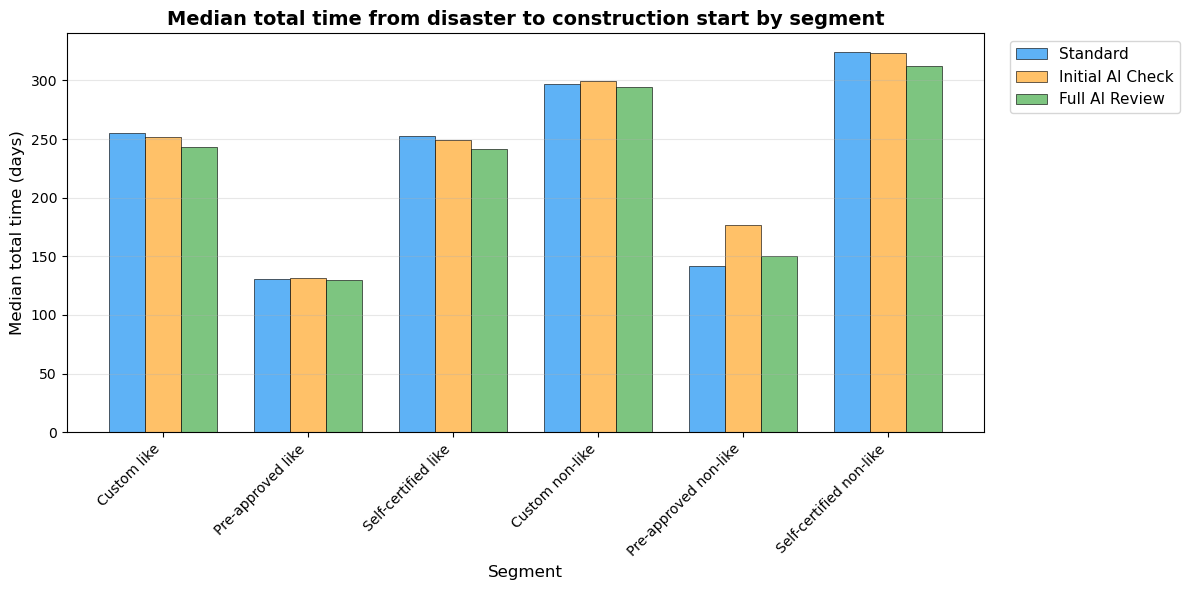

In [4]:
# Compare median total time (disaster to construction) by segment
permits_by_process = {
    "Standard": sim_standard.completed_permits,
    "Initial AI Check": sim_initial.completed_permits,
    "Full AI Review": sim_full.completed_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()